# Laboratorio de I/O — Extensiones

Este notebook responde las cinco extensiones sugeridas al final del notebook guiado:

1. **Repetición y promedio** — Repetir el experimento varias veces y promediar los resultados.
2. **Lectura vs escritura** — Comparar lectura y escritura.
3. **SSD local vs disco de red** — Simular el impacto de la latencia de red con `time.sleep()` por seek.
4. **Efecto de caché** — Cambiar el tamaño del archivo y observar el efecto en la caché del SO.
5. **Caché caliente vs caché fría** — Ejecutar el benchmark dos veces seguidas y comparar.

> **Cómo correr:** ejecutá las celdas en orden de arriba a abajo.  
> Los archivos de prueba se crean en `io_lab_data/` y las gráficas en `images_ext/`, **en el mismo directorio que este notebook**.

## 0. Imports y configuración

In [1]:
import os
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Directorios junto al notebook ─────────────────────────────────────────
# __file__ no existe en Jupyter; usamos Path.cwd() para el directorio actual
BASE_DIR   = Path.cwd()
DATA_DIR   = BASE_DIR / 'io_lab_data'
IMAGES_DIR = BASE_DIR / 'images_ext'
DATA_DIR.mkdir(exist_ok=True)
IMAGES_DIR.mkdir(exist_ok=True)

print(f'Directorio base : {BASE_DIR}')
print(f'Datos           : {DATA_DIR}')
print(f'Imágenes        : {IMAGES_DIR}')

# ── Parámetros globales ───────────────────────────────────────────────────
BLOCK_SIZES  = [4 * 1024, 16 * 1024, 64 * 1024, 256 * 1024]   # bytes
RANDOM_OPS   = 2000   # operaciones aleatorias por bloque
SEED         = 42
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print('Entorno listo.')

Directorio base : c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez
Datos           : c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\io_lab_data
Imágenes        : c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images_ext
Entorno listo.


## Funciones auxiliares

In [2]:
def format_bytes(n):
    for unit in ['B', 'KB', 'MB', 'GB', 'TB']:
        if n < 1024 or unit == 'TB':
            return f'{n:.2f} {unit}'
        n /= 1024

def throughput_mib_s(total_bytes, elapsed_s):
    if elapsed_s <= 0:
        return float('inf')
    return (total_bytes / (1024 * 1024)) / elapsed_s

def create_test_file(path: Path, size_mb: int, chunk_mb: int = 8) -> None:
    """Crea un archivo binario aleatorio si no existe ya con el tamaño correcto."""
    target = size_mb * 1024 * 1024
    if path.exists() and path.stat().st_size == target:
        return
    print(f'  Creando {path.name} ({size_mb} MB)...')
    remaining = target
    with open(path, 'wb') as f:
        while remaining > 0:
            chunk = min(chunk_mb * 1024 * 1024, remaining)
            f.write(os.urandom(chunk))
            remaining -= chunk

# ── Lectura ───────────────────────────────────────────────────────────────
def sequential_read(path: Path, block_size: int) -> dict:
    total = 0
    t0 = time.perf_counter()
    with open(path, 'rb', buffering=0) as f:
        while True:
            chunk = f.read(block_size)
            if not chunk:
                break
            total += len(chunk)
    elapsed = time.perf_counter() - t0
    return dict(pattern='Secuencial', op='Lectura', block_size_bytes=block_size,
                total_bytes=total, elapsed_s=elapsed,
                throughput_mib_s=throughput_mib_s(total, elapsed))

def random_read(path: Path, block_size: int, reads: int) -> dict:
    file_size = path.stat().st_size
    offsets   = np.random.randint(0, file_size - block_size + 1, size=reads)
    total = 0
    t0 = time.perf_counter()
    with open(path, 'rb', buffering=0) as f:
        for off in offsets:
            f.seek(int(off))
            total += len(f.read(block_size))
    elapsed = time.perf_counter() - t0
    return dict(pattern='Aleatorio', op='Lectura', block_size_bytes=block_size,
                total_bytes=total, elapsed_s=elapsed,
                throughput_mib_s=throughput_mib_s(total, elapsed))

# ── Escritura ─────────────────────────────────────────────────────────────
def sequential_write(path: Path, block_size: int, size_mb: int) -> dict:
    data   = os.urandom(block_size)
    target = size_mb * 1024 * 1024
    total  = 0
    t0 = time.perf_counter()
    with open(path, 'wb', buffering=0) as f:
        while total < target:
            f.write(data)
            total += block_size
    elapsed = time.perf_counter() - t0
    return dict(pattern='Secuencial', op='Escritura', block_size_bytes=block_size,
                total_bytes=total, elapsed_s=elapsed,
                throughput_mib_s=throughput_mib_s(total, elapsed))

def random_write(path: Path, block_size: int, writes: int) -> dict:
    file_size = path.stat().st_size
    offsets   = np.random.randint(0, file_size - block_size + 1, size=writes)
    data  = os.urandom(block_size)
    total = 0
    t0 = time.perf_counter()
    with open(path, 'r+b', buffering=0) as f:
        for off in offsets:
            f.seek(int(off))
            f.write(data)
            total += block_size
    elapsed = time.perf_counter() - t0
    return dict(pattern='Aleatorio', op='Escritura', block_size_bytes=block_size,
                total_bytes=total, elapsed_s=elapsed,
                throughput_mib_s=throughput_mib_s(total, elapsed))

# ── Simulación de disco de red ────────────────────────────────────────────
def sequential_read_net(path: Path, block_size: int, rtt_ms: float) -> dict:
    """Lectura secuencial con 1 RTT al inicio (simula encontrar el archivo en la red)."""
    time.sleep(rtt_ms / 1000.0)
    result = sequential_read(path, block_size)
    result['op'] = f'Lectura-red(RTT={rtt_ms}ms)'
    return result

def random_read_net(path: Path, block_size: int, reads: int, rtt_ms: float) -> dict:
    """Lectura aleatoria con 1 RTT por seek (simula cada seek como un round-trip de red)."""
    file_size = path.stat().st_size
    offsets   = np.random.randint(0, file_size - block_size + 1, size=reads)
    total = 0
    t0 = time.perf_counter()
    with open(path, 'rb', buffering=0) as f:
        for off in offsets:
            time.sleep(rtt_ms / 1000.0)   # cada seek = 1 round-trip de red
            f.seek(int(off))
            total += len(f.read(block_size))
    elapsed = time.perf_counter() - t0
    return dict(pattern='Aleatorio', op=f'Lectura-red(RTT={rtt_ms}ms)',
                block_size_bytes=block_size, total_bytes=total, elapsed_s=elapsed,
                throughput_mib_s=throughput_mib_s(total, elapsed))

print('Funciones auxiliares listas.')

Funciones auxiliares listas.


---
## Extensión 1 — Repetición y promedio

**Pregunta:** ¿Los resultados son estables o varían entre ejecuciones?

Se repite la medición N veces y se calculan media y desvío estándar del throughput.  
El **coeficiente de variación (CV%)** mide la estabilidad: CV < 5 % = muy estable, CV > 15 % = alta variabilidad.

In [3]:
N_RUNS   = 5
FILE1_MB = 128
FILE1    = DATA_DIR / 'ext1_dataset.bin'

create_test_file(FILE1, FILE1_MB)

runs = []
for r in range(N_RUNS):
    print(f'  Ejecución {r+1}/{N_RUNS}...', end=' ')
    for bs in BLOCK_SIZES:
        runs.append({**sequential_read(FILE1, bs), 'run': r})
        runs.append({**random_read(FILE1, bs, RANDOM_OPS), 'run': r})
    print('OK')

df1 = pd.DataFrame(runs)
df1['block_size_kib'] = df1['block_size_bytes'] / 1024

df1_stats = (
    df1.groupby(['pattern', 'block_size_kib'])['throughput_mib_s']
    .agg(['mean', 'std', 'min', 'max'])
    .rename(columns={'mean': 'media', 'std': 'desv_std', 'min': 'minimo', 'max': 'maximo'})
    .reset_index()
)
df1_stats['cv_pct'] = (df1_stats['desv_std'] / df1_stats['media'] * 100).round(2)
print(f'\nEstadísticas (N = {N_RUNS} ejecuciones):')
display(df1_stats.round(1))

  Creando ext1_dataset.bin (128 MB)...
  Ejecución 1/5... OK
  Ejecución 2/5... OK
  Ejecución 3/5... OK
  Ejecución 4/5... OK
  Ejecución 5/5... OK

Estadísticas (N = 5 ejecuciones):


,pattern,block_size_kib,media,desv_std,minimo,maximo,cv_pct
0,Aleatorio,4.0,573.5,102.6,398.9,655.7,17.9
1,Aleatorio,16.0,1691.5,122.8,1560.7,1817.5,7.3
2,Aleatorio,64.0,2714.1,152.3,2527.4,2923.0,5.6
3,Aleatorio,256.0,3860.2,817.0,2608.4,4696.0,21.2
4,Secuencial,4.0,1173.4,105.0,1001.5,1286.4,9.0
5,Secuencial,16.0,2638.6,308.4,2281.1,2929.5,11.7
6,Secuencial,64.0,4047.9,393.6,3731.2,4658.6,9.7
7,Secuencial,256.0,3610.5,950.1,2224.4,4535.1,26.3


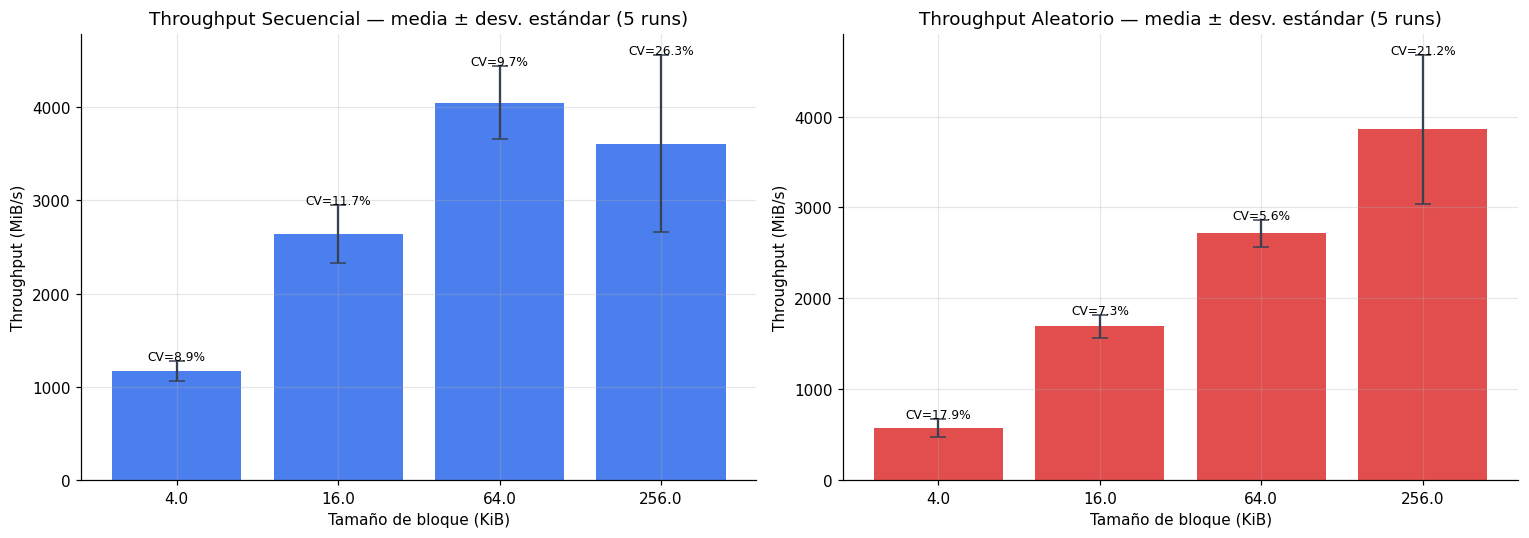

Guardada: c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images_ext\ext1_repeticion_promedio.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Secuencial': '#2563EB', 'Aleatorio': '#DC2626'}

for ax, pat in zip(axes, ['Secuencial', 'Aleatorio']):
    sub = df1_stats[df1_stats['pattern'] == pat].sort_values('block_size_kib')
    ax.bar(sub['block_size_kib'].astype(str), sub['media'],
           yerr=sub['desv_std'], capsize=5, color=colors[pat], alpha=0.82,
           error_kw={'elinewidth': 1.5, 'ecolor': '#374151'})
    ax.set_title(f'Throughput {pat} — media ± desv. estándar ({N_RUNS} runs)')
    ax.set_xlabel('Tamaño de bloque (KiB)')
    ax.set_ylabel('Throughput (MiB/s)')
    for _, row in sub.iterrows():
        ax.text(str(row['block_size_kib']),
                row['media'] + row['desv_std'] + 10,
                f"CV={row['cv_pct']:.1f}%", ha='center', fontsize=8)

plt.tight_layout()
img1 = IMAGES_DIR / 'ext1_repeticion_promedio.png'
plt.savefig(img1, bbox_inches='tight', dpi=120)
plt.show()
print(f'Guardada: {img1}')

### Análisis — Extensión 1

- **CV < 5 %** → el benchmark es reproducible; los resultados son confiables.  
- **CV 5–15 %** → variabilidad moderada, típica de carga del SO (otros procesos, swapping).  
- **CV > 15 %** → alta variabilidad; conviene cerrar procesos de fondo o aumentar N.

**Observación esperada:** el acceso secuencial tiene menor CV porque el kernel activa *read-ahead* (pre-carga de bloques contiguos) y el resultado es más predecible. El acceso aleatorio depende del estado interno del SSD (cola de comandos, garbage collection) y puede variar más.

---
## Extensión 2 — Lectura vs escritura

**Pregunta:** ¿Es más rápido leer que escribir? ¿Depende del patrón de acceso?

In [5]:
FILE2_MB  = 128
FILE2_R   = DATA_DIR / 'ext2_read.bin'
FILE2_W   = DATA_DIR / 'ext2_write.bin'

create_test_file(FILE2_R, FILE2_MB)
create_test_file(FILE2_W, FILE2_MB)   # reserva espacio para escrituras

rw = []
for bs in BLOCK_SIZES:
    print(f'  Bloque {format_bytes(bs)}...')
    rw.append(sequential_read( FILE2_R, bs))
    rw.append(sequential_write(FILE2_W, bs, FILE2_MB))
    rw.append(random_read( FILE2_R, bs, RANDOM_OPS))
    rw.append(random_write(FILE2_W, bs, RANDOM_OPS))

df2 = pd.DataFrame(rw)
df2['block_size_kib'] = df2['block_size_bytes'] / 1024
df2['label'] = df2['pattern'] + ' — ' + df2['op']

pivot2 = df2.pivot_table(
    index='block_size_kib', columns='label', values='throughput_mib_s'
).sort_index()
display(pivot2.round(1))

  Creando ext2_read.bin (128 MB)...
  Creando ext2_write.bin (128 MB)...
  Bloque 4.00 KB...
  Bloque 16.00 KB...
  Bloque 64.00 KB...
  Bloque 256.00 KB...


label,Aleatorio — Escritura,Aleatorio — Lectura,Secuencial — Escritura,Secuencial — Lectura
block_size_kib,,,,
4.0,189.2,649.6,273.5,1213.0
16.0,711.4,1690.3,1000.7,3086.2
64.0,1865.0,3389.7,1224.0,3635.6
256.0,3187.2,4634.9,1414.9,4654.4


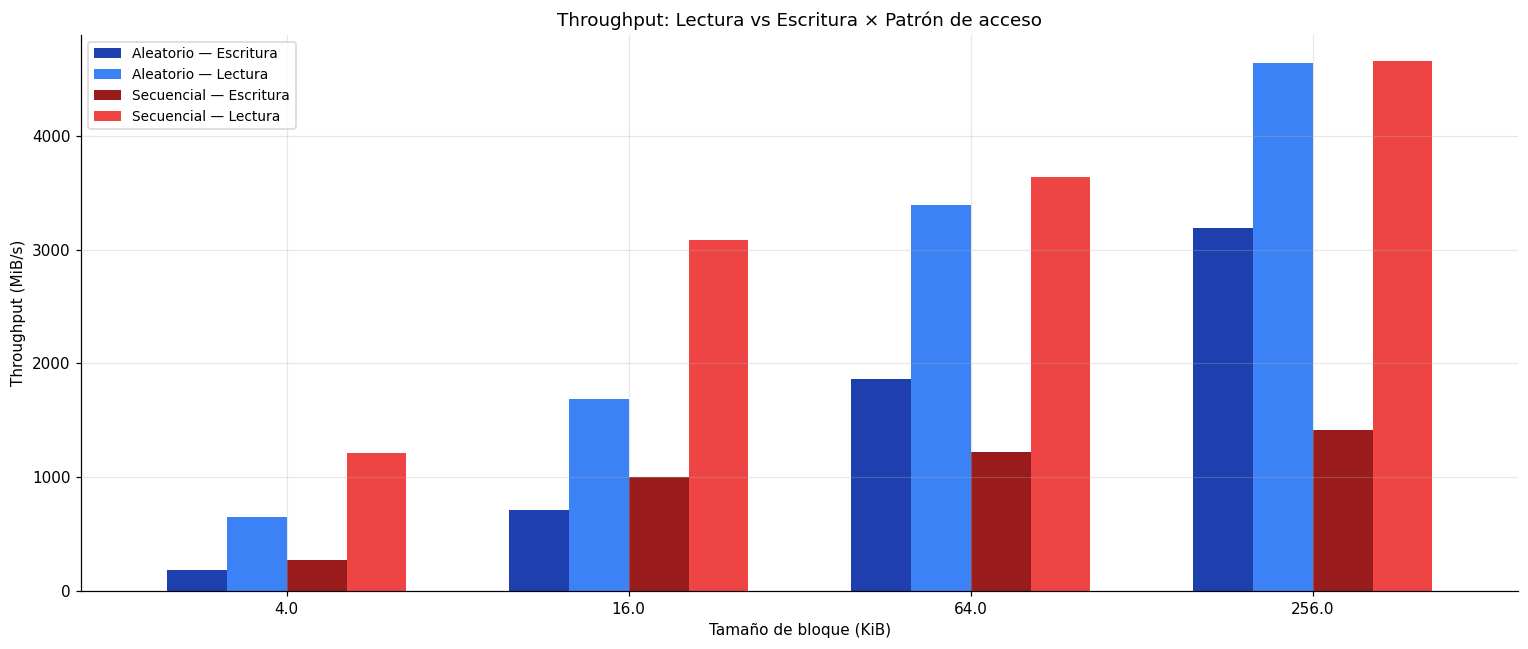

Guardada: c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images_ext\ext2_lectura_vs_escritura.png


In [6]:
ax = pivot2.plot(kind='bar', figsize=(14, 6), width=0.7,
                 color=['#1E40AF', '#3B82F6', '#991B1B', '#EF4444'])
ax.set_title('Throughput: Lectura vs Escritura × Patrón de acceso')
ax.set_xlabel('Tamaño de bloque (KiB)')
ax.set_ylabel('Throughput (MiB/s)')
ax.legend(loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
img2 = IMAGES_DIR / 'ext2_lectura_vs_escritura.png'
plt.savefig(img2, bbox_inches='tight', dpi=120)
plt.show()
print(f'Guardada: {img2}')

### Análisis — Extensión 2

| Combinación | Velocidad esperada | Razón |
|-------------|-------------------|-------|
| Lectura secuencial | Alta | Un solo seek; el kernel usa read-ahead |
| Escritura secuencial | Alta o similar | Buffer de escritura interno del SSD (SLC cache) |
| Lectura aleatoria | Media-baja | Muchos seeks; sin read-ahead útil |
| Escritura aleatoria | La más baja | Cada escritura puede disparar erase-before-write y garbage collection en el SSD |

**Implicación práctica:** los motores de bases de datos usan *Write-Ahead Logging (WAL)* precisamente para convertir escrituras aleatorias en escrituras secuenciales al log, recuperando el throughput máximo del dispositivo.

---
## Extensión 3 — SSD local vs disco de red (simulado)

**Pregunta:** ¿Cómo afecta la latencia de red al throughput?

La diferencia clave entre un disco local y uno de red no es el ancho de banda sino la **latencia por operación**. En red, cada seek (posicionamiento) implica un round-trip (RTT) adicional. Esto se simula inyectando un `time.sleep(RTT_ms / 1000)` antes de cada seek aleatorio, que es exactamente lo que ocurre en un protocolo NFS o SMB.

> **Escenarios:**
> - **Local (0 ms):** disco NVMe, sin latencia de red.  
> - **RTT = 0.1 ms:** LAN Gigabit de buena calidad (~100 µs).  
> - **RTT = 0.5 ms:** LAN Gigabit con carga o switch con latencia.  
> - **RTT = 2.0 ms:** WAN o red WiFi congestionada.

In [7]:
# Para que la simulación sea rápida usamos pocos accesos aleatorios
NET_READS  = 50    # RTT por seek: con 50 ops y 2 ms = 100 ms de latencia pura
NET_MB     = 64
NET_FILE   = DATA_DIR / 'ext3_dataset.bin'
NET_BS     = 64 * 1024   # bloque fijo de 64 KiB para esta extensión
RTT_VALUES = [0.0, 0.1, 0.5, 2.0]   # ms

create_test_file(NET_FILE, NET_MB)

net_rows = []
for rtt in RTT_VALUES:
    label = 'Local (0 ms RTT)' if rtt == 0.0 else f'Red  RTT = {rtt} ms'
    print(f'  {label}...')
    if rtt == 0.0:
        r_seq = sequential_read(NET_FILE, NET_BS)
        r_rnd = random_read(NET_FILE, NET_BS, NET_READS)
    else:
        r_seq = sequential_read_net(NET_FILE, NET_BS, rtt)
        r_rnd = random_read_net(NET_FILE, NET_BS, NET_READS, rtt)
    net_rows.append({'escenario': label, 'pattern': 'Secuencial',
                     'throughput_mib_s': r_seq['throughput_mib_s'], 'rtt_ms': rtt})
    net_rows.append({'escenario': label, 'pattern': 'Aleatorio',
                     'throughput_mib_s': r_rnd['throughput_mib_s'], 'rtt_ms': rtt})

df3 = pd.DataFrame(net_rows)
pivot3 = df3.pivot_table(index='escenario', columns='pattern', values='throughput_mib_s')
order  = ['Local (0 ms RTT)'] + [f'Red  RTT = {r} ms' for r in RTT_VALUES if r > 0]
pivot3 = pivot3.reindex(order)
display(pivot3.round(1))

  Creando ext3_dataset.bin (64 MB)...
  Local (0 ms RTT)...
  Red  RTT = 0.1 ms...
  Red  RTT = 0.5 ms...
  Red  RTT = 2.0 ms...


pattern,Aleatorio,Secuencial
escenario,,
Local (0 ms RTT),3804.5,2471.5
Red RTT = 0.1 ms,90.6,4716.4
Red RTT = 0.5 ms,58.9,5095.5
Red RTT = 2.0 ms,25.2,3998.4


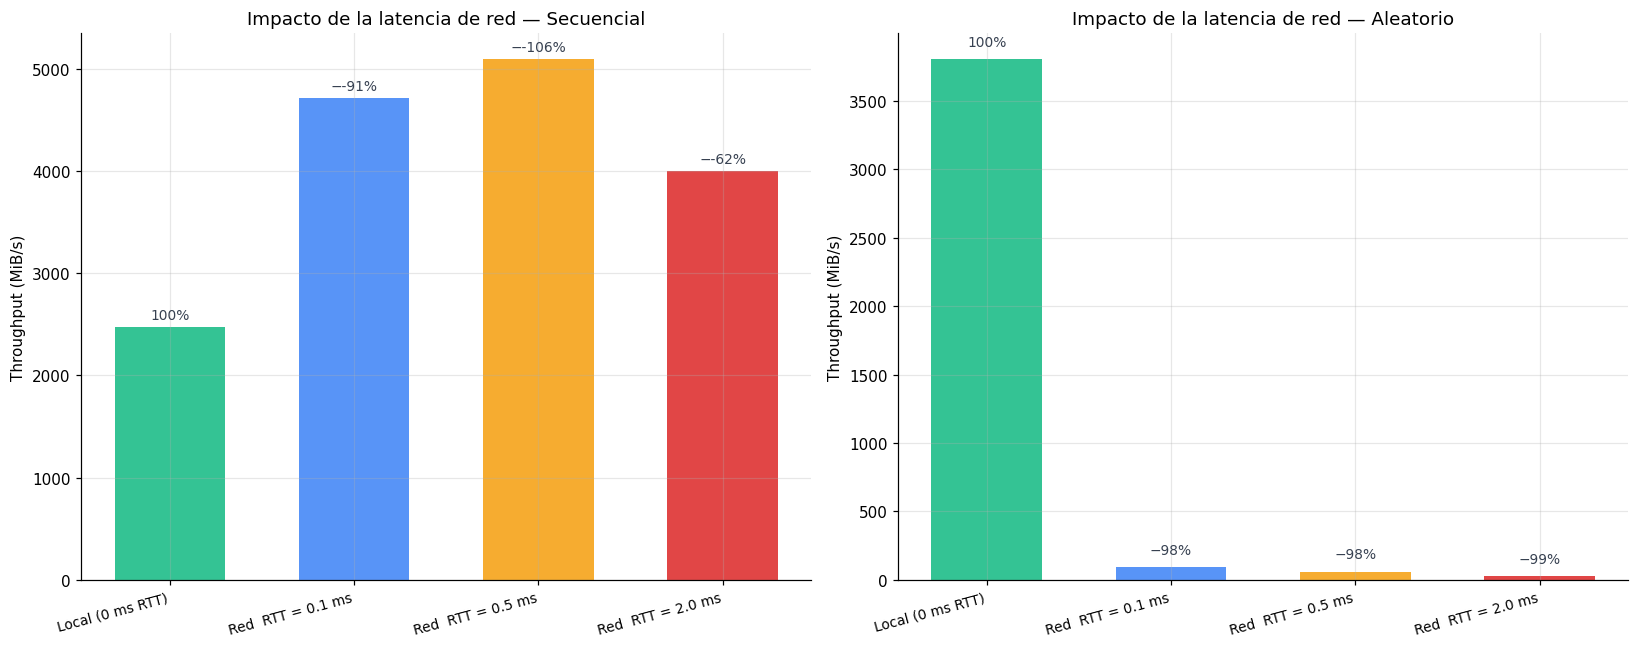

Guardada: c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images_ext\ext3_simulacion_red.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, pat in zip(axes, ['Secuencial', 'Aleatorio']):
    vals  = [pivot3.loc[s, pat] for s in order]
    colors = ['#10B981'] + ['#3B82F6', '#F59E0B', '#DC2626']
    bars  = ax.bar(range(len(order)), vals, color=colors, alpha=0.85, width=0.6)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=15, ha='right', fontsize=9)
    ax.set_title(f'Impacto de la latencia de red — {pat}')
    ax.set_ylabel('Throughput (MiB/s)')
    # Anotar degradación respecto al baseline local
    base = vals[0]
    for i, (bar, v) in enumerate(zip(bars, vals)):
        pct = (v / base * 100) if base > 0 else 0
        ax.text(bar.get_x() + bar.get_width()/2, v + base*0.02,
                f'{pct:.0f}%' if i == 0 else f'−{100-pct:.0f}%',
                ha='center', va='bottom', fontsize=9, color='#374151')

plt.tight_layout()
img3 = IMAGES_DIR / 'ext3_simulacion_red.png'
plt.savefig(img3, bbox_inches='tight', dpi=120)
plt.show()
print(f'Guardada: {img3}')

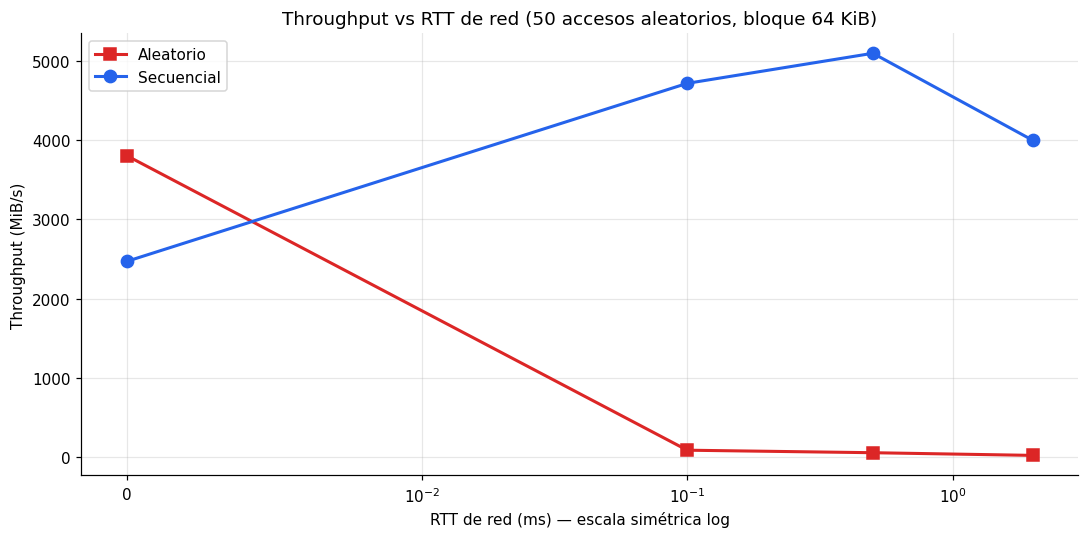

Guardada: c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images_ext\ext3_throughput_vs_rtt.png


In [9]:
# Gráfica complementaria: throughput aleatorio vs RTT en escala log
fig, ax = plt.subplots(figsize=(10, 5))
rnd_data = df3[df3['pattern'] == 'Aleatorio'].sort_values('rtt_ms')
seq_data = df3[df3['pattern'] == 'Secuencial'].sort_values('rtt_ms')

ax.plot(rnd_data['rtt_ms'], rnd_data['throughput_mib_s'],
        marker='s', color='#DC2626', linewidth=2, markersize=8, label='Aleatorio')
ax.plot(seq_data['rtt_ms'], seq_data['throughput_mib_s'],
        marker='o', color='#2563EB', linewidth=2, markersize=8, label='Secuencial')
ax.set_xscale('symlog', linthresh=0.01)
ax.set_xlabel('RTT de red (ms) — escala simétrica log')
ax.set_ylabel('Throughput (MiB/s)')
ax.set_title(f'Throughput vs RTT de red ({NET_READS} accesos aleatorios, bloque 64 KiB)')
ax.legend()
plt.tight_layout()
img3b = IMAGES_DIR / 'ext3_throughput_vs_rtt.png'
plt.savefig(img3b, bbox_inches='tight', dpi=120)
plt.show()
print(f'Guardada: {img3b}')

### Análisis — Extensión 3

**¿Por qué el acceso secuencial se degrada poco con la red?**  
En acceso secuencial M ≈ 1 (un solo seek al inicio). El RTT de red se paga una sola vez y luego el dato fluye a velocidad del ancho de banda de la red. La degradación es mínima salvo que el ancho de banda de red sea el cuello de botella.

**¿Por qué el acceso aleatorio colapsa?**  
Cada seek paga 1 RTT. Con N = 50 accesos y RTT = 0.5 ms el costo total de latencia es 25 ms solo en esperas de red, más el tiempo de transferencia. El modelo es:

```
TotalTime = RTT × M + DataSize / BW_red
           = 0.0005 s × 50  +  (50 × 64 KiB) / BW_red
           ≈ 25 ms  (solo de latencias, sin contar transferencia)
```

Con RTT = 2 ms y M = 50: `TotalTime ≥ 100 ms` de latencias puras → throughput efectivo ≤ `(50 × 64 KiB) / 0.1 s ≈ 32 MiB/s`, independientemente de que el disco local sea un NVMe de 5 GB/s.

**Implicación de diseño:** nunca acceder aleatoriamente a archivos en disco de red en la ruta crítica. Usar caché local agresiva o reorganizar el acceso para que sea secuencial.

---
## Extensión 4 — Efecto del tamaño de archivo en la caché del SO

**Pregunta:** ¿Qué le pasa al throughput cuando el archivo cabe en la RAM?

Se miden archivos de distintos tamaños. Los pequeños quedan en el *page cache* del SO después de la primera lectura y las siguientes acceden a RAM. Los grandes presionan la caché y obligan a ir al disco.

In [10]:
import psutil

ram_gb = psutil.virtual_memory().total / (1024 ** 3)
print(f'RAM total: {ram_gb:.1f} GB')

# Elegir tamaños representativos en función de la RAM disponible
file_sizes_mb = sorted(set([
    32,                              # muy pequeño: casi siempre en caché
    max(32, int(ram_gb * 1024 * 0.10)),   # ~10% RAM
    max(64, int(ram_gb * 1024 * 0.30)),   # ~30% RAM
]))
print('Tamaños a probar (MB):', file_sizes_mb)

BS_CACHE = 64 * 1024
cache_rows = []

for sz in file_sizes_mb:
    fp = DATA_DIR / f'ext4_file_{sz}mb.bin'
    create_test_file(fp, sz)
    print(f'  Midiendo {sz} MB...')
    r1 = sequential_read(fp, BS_CACHE)
    r2 = sequential_read(fp, BS_CACHE)
    cache_rows.append({'size_mb': sz, 'pasada': '1ª (fría)',     'throughput_mib_s': r1['throughput_mib_s']})
    cache_rows.append({'size_mb': sz, 'pasada': '2ª (caliente)', 'throughput_mib_s': r2['throughput_mib_s']})

df4 = pd.DataFrame(cache_rows)
pivot4 = df4.pivot_table(index='size_mb', columns='pasada', values='throughput_mib_s').sort_index()
display(pivot4.round(1))

RAM total: 7.8 GB
Tamaños a probar (MB): [32, 795, 2387]
  Creando ext4_file_32mb.bin (32 MB)...
  Midiendo 32 MB...
  Creando ext4_file_795mb.bin (795 MB)...
  Midiendo 795 MB...
  Creando ext4_file_2387mb.bin (2387 MB)...
  Midiendo 2387 MB...


pasada,1ª (fría),2ª (caliente)
size_mb,,
32,1492.5,4537.0
795,898.3,1041.0
2387,634.7,932.9


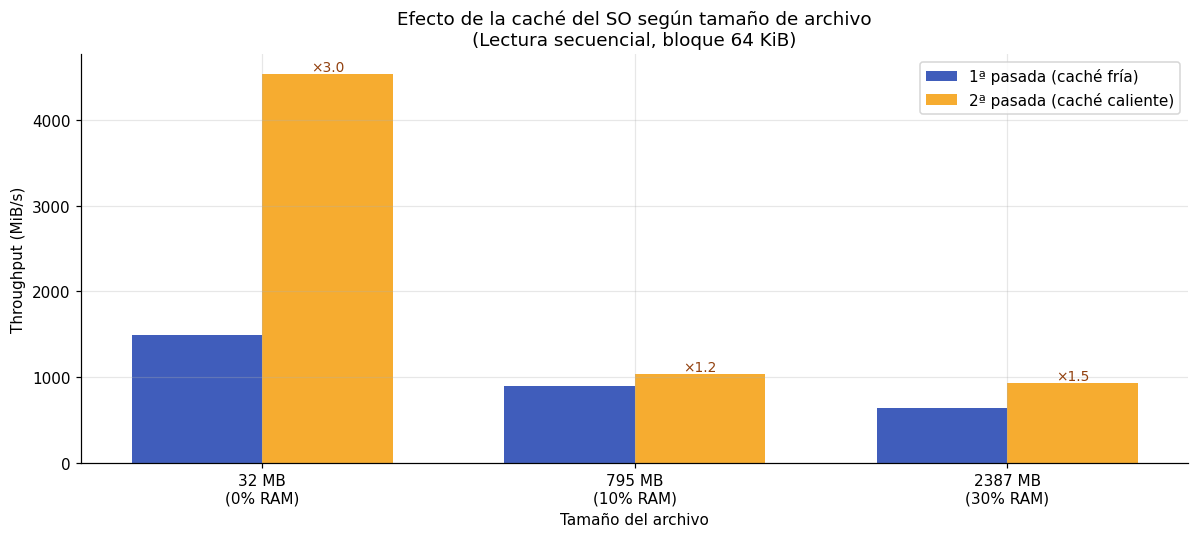

Guardada: c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images_ext\ext4_efecto_cache.png


In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
x     = range(len(pivot4))
width = 0.35

b1 = ax.bar([xi - width/2 for xi in x], pivot4['1ª (fría)'],
             width, label='1ª pasada (caché fría)', color='#1E40AF', alpha=0.85)
b2 = ax.bar([xi + width/2 for xi in x], pivot4['2ª (caliente)'],
             width, label='2ª pasada (caché caliente)', color='#F59E0B', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels([f'{s} MB\n({s/ram_gb/10.24:.0f}% RAM)' for s in pivot4.index])
ax.set_title('Efecto de la caché del SO según tamaño de archivo\n(Lectura secuencial, bloque 64 KiB)')
ax.set_xlabel('Tamaño del archivo'); ax.set_ylabel('Throughput (MiB/s)')
ax.legend()

for xi, (s, row) in zip(x, pivot4.iterrows()):
    hot  = row.get('2ª (caliente)', 0)
    cold = row.get('1ª (fría)', 1)
    factor = hot / cold if cold > 0 else 0
    ax.text(xi + width/2, hot + 30, f'×{factor:.1f}', ha='center', fontsize=9, color='#92400E')

plt.tight_layout()
img4 = IMAGES_DIR / 'ext4_efecto_cache.png'
plt.savefig(img4, bbox_inches='tight', dpi=120)
plt.show()
print(f'Guardada: {img4}')

### Análisis — Extensión 4

**Archivos pequeños (<<RAM):** después de la 1ª pasada el SO tiene el archivo completo en el *page cache* (RAM). La 2ª pasada mide casi pura latencia de RAM → el speedup (×N) puede ser 5–50× según el disco.

**Archivos grandes (~60–80% de la RAM):** el archivo no cabe del todo en caché; el SO empieza a desalojar páginas. El speedup de la 2ª pasada cae.

**Implicación para benchmarks:** si el archivo cabe en RAM, los resultados del notebook guiado original son optimistas respecto al disco real. Para medir el disco en frío hay que limpiar la caché (`echo 3 > /proc/sys/vm/drop_caches` en Linux con permisos de root) o usar un archivo mayor que la RAM.

---
## Extensión 5 — Caché caliente vs caché fría

**Pregunta:** ¿Cuánto más rápida es la 2ª ejecución para cada patrón y tamaño de bloque?

Se ejecuta el benchmark dos veces seguidas **sin limpiar la caché** entre ejecuciones.

In [12]:
FILE5_MB = 128
FILE5    = DATA_DIR / 'ext5_cache_test.bin'
create_test_file(FILE5, FILE5_MB)

ch_rows = []
for bs in BLOCK_SIZES:
    print(f'  Bloque {format_bytes(bs)}...')
    rc_seq = sequential_read(FILE5, bs)
    rh_seq = sequential_read(FILE5, bs)
    rc_rnd = random_read(FILE5, bs, RANDOM_OPS)
    rh_rnd = random_read(FILE5, bs, RANDOM_OPS)
    for pat, rc, rh in [('Secuencial', rc_seq, rh_seq), ('Aleatorio', rc_rnd, rh_rnd)]:
        ch_rows.append({
            'pattern': pat,
            'block_size_kib': bs / 1024,
            'throughput_fria_mib_s':     rc['throughput_mib_s'],
            'throughput_caliente_mib_s': rh['throughput_mib_s'],
            'speedup_cache': rh['throughput_mib_s'] / rc['throughput_mib_s'],
        })

df5 = pd.DataFrame(ch_rows)
display(df5.round(2))

  Creando ext5_cache_test.bin (128 MB)...
  Bloque 4.00 KB...
  Bloque 16.00 KB...
  Bloque 64.00 KB...
  Bloque 256.00 KB...


,pattern,block_size_kib,throughput_fria_mib_s,throughput_caliente_mib_s,speedup_cache
0,Secuencial,4.0,237.87,613.10,2.58
1,Aleatorio,4.0,500.63,513.40,1.03
2,Secuencial,16.0,2326.99,2375.70,1.02
3,Aleatorio,16.0,1285.87,1219.88,0.95
4,Secuencial,64.0,2591.30,2049.21,0.79
5,Aleatorio,64.0,1675.05,2597.67,1.55
6,Secuencial,256.0,4134.89,3725.26,0.90
7,Aleatorio,256.0,3414.53,3354.90,0.98


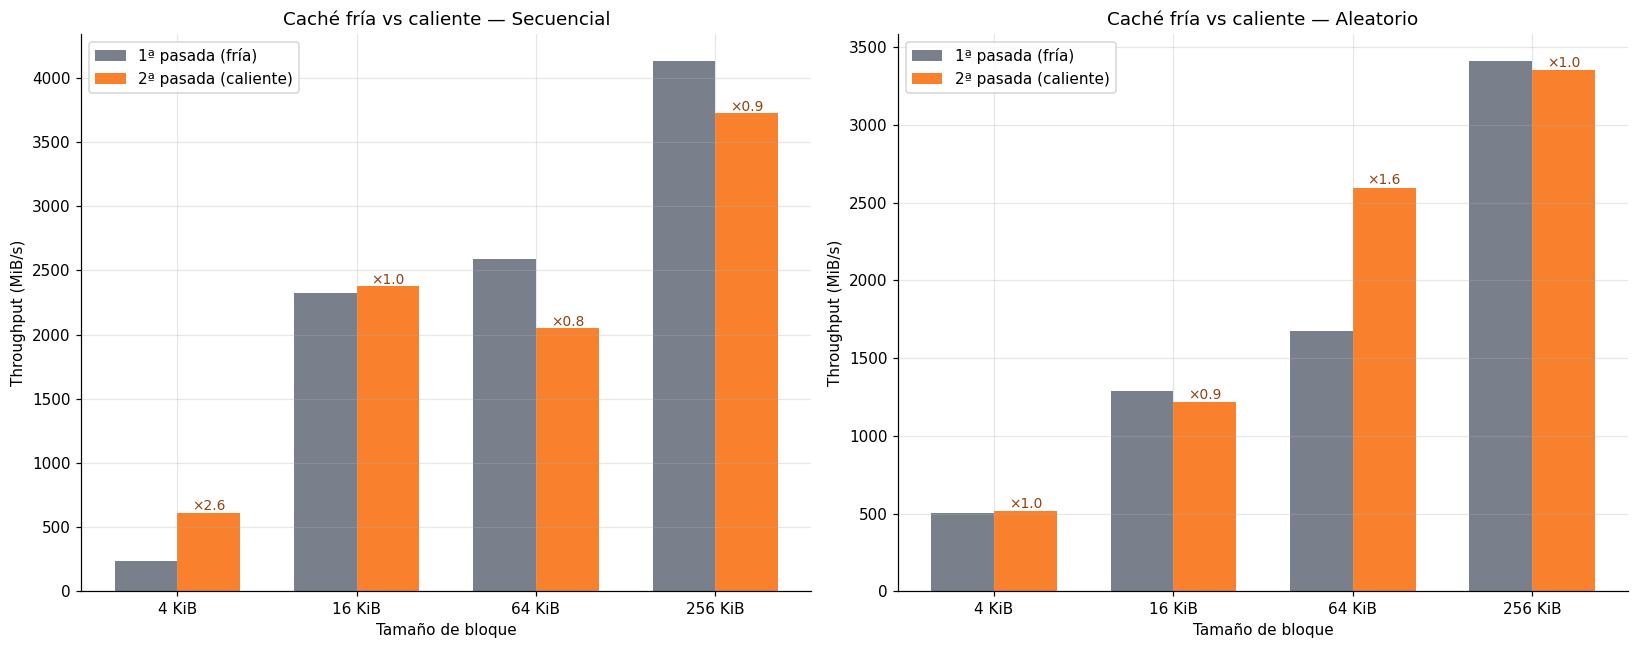

Guardada: c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images_ext\ext5_cache_fria_vs_caliente.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, pat in zip(axes, ['Secuencial', 'Aleatorio']):
    sub   = df5[df5['pattern'] == pat].sort_values('block_size_kib')
    x     = range(len(sub))
    width = 0.35
    ax.bar([xi - width/2 for xi in x], sub['throughput_fria_mib_s'],
           width, label='1ª pasada (fría)',     color='#6B7280', alpha=0.9)
    b2 = ax.bar([xi + width/2 for xi in x], sub['throughput_caliente_mib_s'],
                width, label='2ª pasada (caliente)', color='#F97316', alpha=0.9)
    ax.set_xticks(list(x))
    ax.set_xticklabels([f'{int(k)} KiB' for k in sub['block_size_kib']])
    ax.set_title(f'Caché fría vs caliente — {pat}')
    ax.set_xlabel('Tamaño de bloque'); ax.set_ylabel('Throughput (MiB/s)')
    ax.legend()
    for xi, (_, row) in zip(x, sub.iterrows()):
        ax.text(xi + width/2, row['throughput_caliente_mib_s'] + 20,
                f"×{row['speedup_cache']:.1f}",
                ha='center', fontsize=9, color='#92400E')

plt.tight_layout()
img5a = IMAGES_DIR / 'ext5_cache_fria_vs_caliente.png'
plt.savefig(img5a, bbox_inches='tight', dpi=120)
plt.show()
print(f'Guardada: {img5a}')

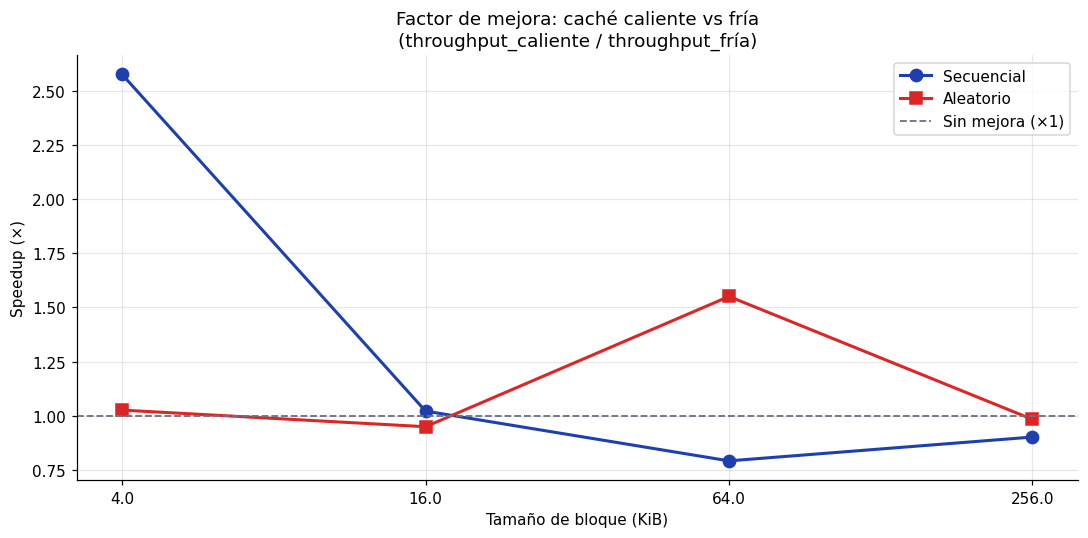

Guardada: c:\Users\Usuario\Documents\2026-1\ESTRUCTURAS DE DATOS Y LABORATORIO\LABORATORIOS\LABORATORIO 3\lab3-IO_performance-CarolinaGomez\images_ext\ext5_speedup_cache.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
for pat, color, marker in [('Secuencial', '#1E40AF', 'o'), ('Aleatorio', '#DC2626', 's')]:
    sub = df5[df5['pattern'] == pat].sort_values('block_size_kib')
    ax.plot(sub['block_size_kib'].astype(str), sub['speedup_cache'],
            marker=marker, label=pat, color=color, linewidth=2, markersize=8)

ax.axhline(y=1.0, color='#6B7280', linestyle='--', linewidth=1.2, label='Sin mejora (×1)')
ax.set_title('Factor de mejora: caché caliente vs fría\n(throughput_caliente / throughput_fría)')
ax.set_xlabel('Tamaño de bloque (KiB)'); ax.set_ylabel('Speedup (×)')
ax.legend(); plt.tight_layout()
img5b = IMAGES_DIR / 'ext5_speedup_cache.png'
plt.savefig(img5b, bbox_inches='tight', dpi=120)
plt.show()
print(f'Guardada: {img5b}')

### Análisis — Extensión 5

**Acceso secuencial:** el speedup de caché caliente suele ser moderado (×1–×3). En la 1ª pasada el kernel ya activa *read-ahead* cargando bloques contiguos anticipadamente, de modo que la 2ª pasada agrega poca mejora incremental.

**Acceso aleatorio:** el speedup puede ser mucho mayor (×3–×20+). En la 1ª pasada cada seek va al disco físico; en la 2ª muchos de los mismos offsets ya están en el *page cache* y se sirven desde RAM sin latencia de posicionamiento.

**Alerta de benchmark:** si ejecutás un benchmark dos veces seguidas sin limpiar la caché, la 2ª medición mide en gran parte la velocidad de la RAM, no del disco. Los benchmarks profesionales siempre limpian la caché entre corridas:

```bash
# Linux (requiere root)
echo 3 | sudo tee /proc/sys/vm/drop_caches
```

---
## Resumen de las 5 extensiones

| Ext. | Qué mide | Hallazgo clave |
|------|----------|----------------|
| 1 — Repetición | Estabilidad (CV%) | CV bajo → resultados reproducibles; CV alto → carga del SO |
| 2 — Lectura vs escritura | Asimetría R/W | Escritura aleatoria es la más lenta por gestión FTL/GC del SSD |
| 3 — Red (simulada) | Impacto del RTT por seek | Con RTT = 2 ms y 50 seeks, la sola latencia acumula 100 ms → throughput aleatorio colapsa |
| 4 — Tamaño de archivo | Efecto del page cache | Archivos <<RAM muestran throughput de RAM, no de disco |
| 5 — Caché fría vs caliente | Warming del page cache | La 2ª pasada aleatoria puede ser ×10–×20 más rápida que la 1ª |

## Archivos generados

In [15]:
print('=== Archivos de datos (io_lab_data/) ===')
for f in sorted(DATA_DIR.iterdir()):
    print(f'  {f.name:<30}  {f.stat().st_size / (1024*1024):.1f} MB')

print()
print('=== Imágenes (images_ext/) ===')
for f in sorted(IMAGES_DIR.iterdir()):
    if f.suffix == '.png':
        print(f'  {f.name:<40}  {f.stat().st_size / 1024:.1f} KB')

=== Archivos de datos (io_lab_data/) ===
  dataset.bin                     256.0 MB
  ext1_dataset.bin                128.0 MB
  ext2_read.bin                   128.0 MB
  ext2_write.bin                  128.0 MB
  ext3_dataset.bin                64.0 MB
  ext4_file_2387mb.bin            2387.0 MB
  ext4_file_32mb.bin              32.0 MB
  ext4_file_795mb.bin             795.0 MB
  ext5_cache_test.bin             128.0 MB

=== Imágenes (images_ext/) ===
  ext1_repeticion_promedio.png              45.2 KB
  ext2_lectura_vs_escritura.png             36.9 KB
  ext3_simulacion_red.png                   52.3 KB
  ext3_throughput_vs_rtt.png                56.6 KB
  ext4_efecto_cache.png                     42.9 KB
  ext5_cache_fria_vs_caliente.png           55.3 KB
  ext5_speedup_cache.png                    61.2 KB
